<a href="https://colab.research.google.com/github/tanishakholiya2/MultiModalMRI/blob/main/MultiModalMRI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Problem 1A

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os
import glob
from scipy.ndimage import convolve, gaussian_filter
from scipy.stats import linregress
import random
from PIL import Image
%pip install opencv-python
import cv2


allfiles = [f for f in os.listdir('brain_mri-2')]
file = random.choice(allfiles)
path = os.path.join('brain_mri-2', file)

img = Image.open(path).convert('L')
img_gray = np.array(img)
img_float = img_gray.astype(np.float64)

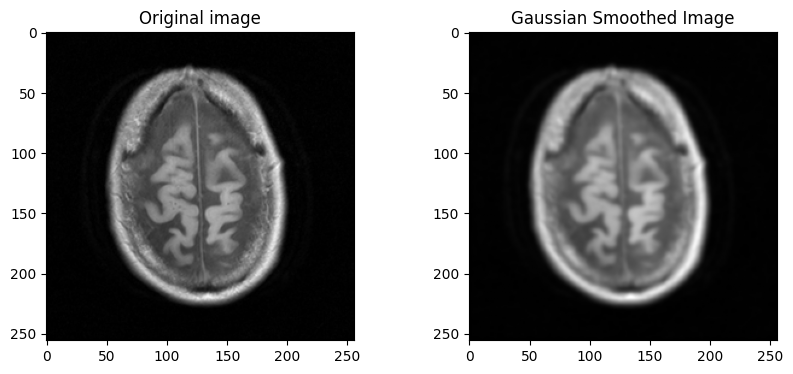

In [ ]:
smooth = gaussian_filter(img_float.astype(np.float64), sigma=1.4)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1);
plt.imshow(img_float,cmap='gray');
plt.title('Original image');
plt.subplot(1,2,2);
plt.imshow(smooth,cmap='gray');
plt.title('Gaussian Smoothed Image');
plt.show()

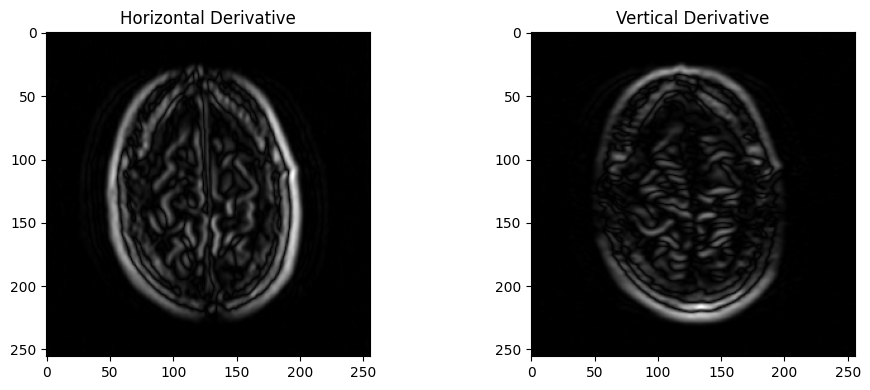

In [ ]:
# x and y derivative images using arrays from lecture
def gradients(image):
    Gx = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]], dtype=np.float64)
    Gy = np.array([[1,2,1],
                   [ 0, 0, 0],
                   [-1,-2,-1]], dtype=np.float64)
    x = convolve(image, Gx)
    y = convolve(image, Gy)
    return x, y

Gx, Gy = gradients(smooth)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1);
plt.imshow(np.abs(Gx), cmap='gray');
plt.title('Horizontal Derivative');
plt.subplot(1,2,2);
plt.imshow(np.abs(Gy), cmap='gray');
plt.title('Vertical Derivative');
plt.tight_layout();
plt.show()

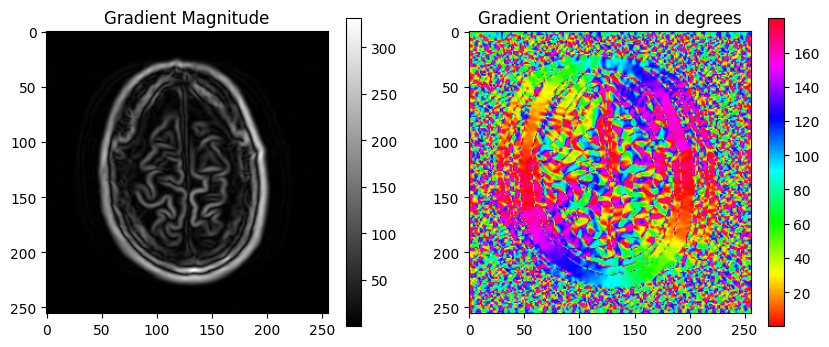

In [ ]:
def gradient_magnitude_orientation(Gx, Gy):
    magnitude = np.hypot(Gx, Gy)
    orientation = np.degrees(np.arctan2(Gy, Gx)) % 180
    return magnitude, orientation

magnitude, orientation = gradient_magnitude_orientation(Gx, Gy)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(magnitude, cmap='gray')
plt.title('Gradient Magnitude')
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(orientation, cmap='hsv')
plt.title('Gradient Orientation in degrees')
plt.colorbar()
plt.show()

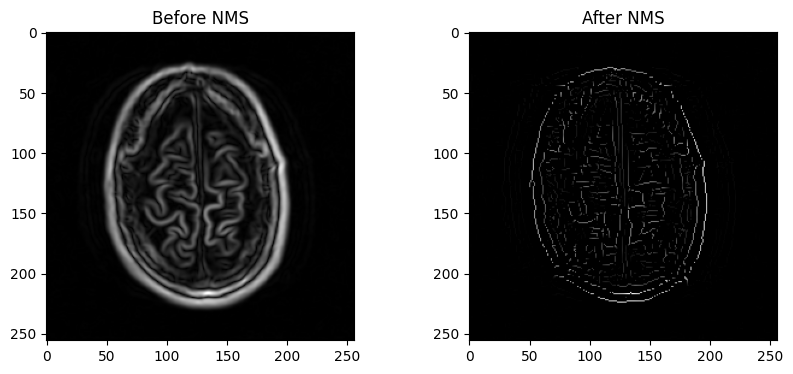

In [ ]:
def non_maximum_suppression(magnitude, orientation):
    height, width = magnitude.shape
    suppressed = np.zeros_like(magnitude)

    for i in range(1, height-1):
        for j in range(1, width-1):
            angle = orientation[i, j]
            if (0 <= angle < 22.5) or (157.5 <= angle < 180):
                n1, n2 = magnitude[i, j+1], magnitude[i, j-1]
            elif 22.5 <= angle < 67.5:
                n1, n2 = magnitude[i-1, j+1], magnitude[i+1, j-1]
            elif 67.5 <= angle < 112.5:
                n1, n2 = magnitude[i-1, j],   magnitude[i+1, j]
            else:
                n1, n2 = magnitude[i+1, j+1], magnitude[i-1, j-1]
            if magnitude[i, j] >= n1 and magnitude[i, j] >= n2:
                suppressed[i, j] = magnitude[i, j]
    return suppressed


suppressed = non_maximum_suppression(magnitude, orientation)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1);
plt.imshow(magnitude, cmap='gray');
plt.title('Before NMS');
plt.subplot(1,2,2);
plt.imshow(suppressed,  cmap='gray');
plt.title('After NMS');
plt.show()


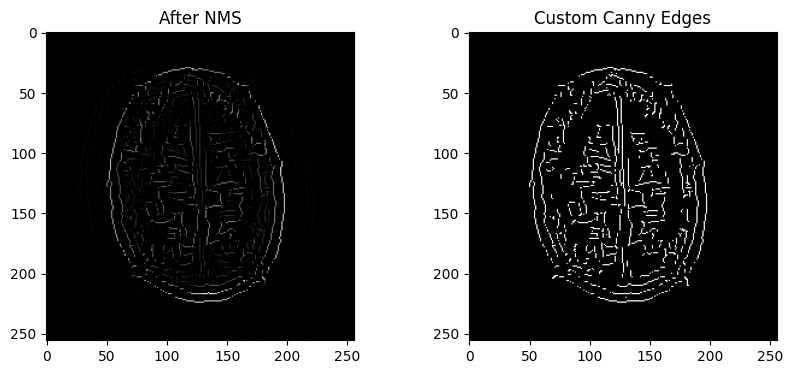

In [ ]:
def hysteresis_thresholding(suppressed, low_ratio=0.05, high_ratio=0.15):
    high_thresh = suppressed.max() * high_ratio
    low_thresh  = high_thresh * low_ratio

    strong_val, weak_val = 255, 75
    result = np.zeros_like(suppressed, dtype=np.uint8)
    result[suppressed >= high_thresh] = strong_val
    result[(suppressed >= low_thresh) & (suppressed < high_thresh)] = weak_val

    height, width = result.shape
    for i in range(1, height-1):
        for j in range(1, width-1):
            if result[i, j] == weak_val:
                if strong_val in result[i-1:i+2, j-1:j+2]:
                    result[i, j] = strong_val
                else:
                    result[i, j] = 0
    return result

hystersis = hysteresis_thresholding(suppressed, low_ratio=0.05, high_ratio=0.15)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1);
plt.imshow(suppressed,    cmap='gray');
plt.title('After NMS');
plt.subplot(1,2,2);
plt.imshow(hystersis,  cmap='gray');
plt.title('Custom Canny Edges');
plt.show()


Problem 1b

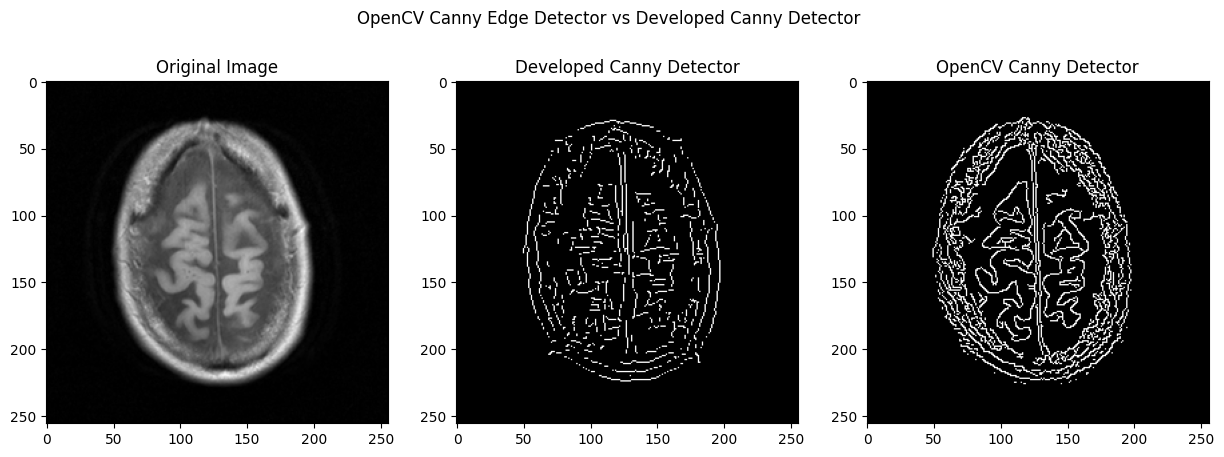

Overlap: 1,175


In [ ]:
img_uint8 = cv2.normalize(img_float, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

#open cv canny
opencv_edges = cv2.Canny(img_uint8, threshold1=50, threshold2=150)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_float,    cmap='gray');
axes[0].set_title('Original Image');
axes[1].imshow(hystersis, cmap='gray');
axes[1].set_title('Developed Canny Detector');
axes[2].imshow(opencv_edges, cmap='gray');
axes[2].set_title('OpenCV Canny Detector');
plt.suptitle('OpenCV Canny Edge Detector vs Developed Canny Detector')
plt.show()

overlap = np.sum((hystersis > 0) & (opencv_edges > 0))
print(f'Overlap: {overlap:,}')


problem 2

          x          y  label
0 -2.509198  -3.852764      1
1  9.014286  19.516345      1
2  4.639879  10.040171      1
3  1.973170   4.853510      1
4 -6.879627 -13.312422      1


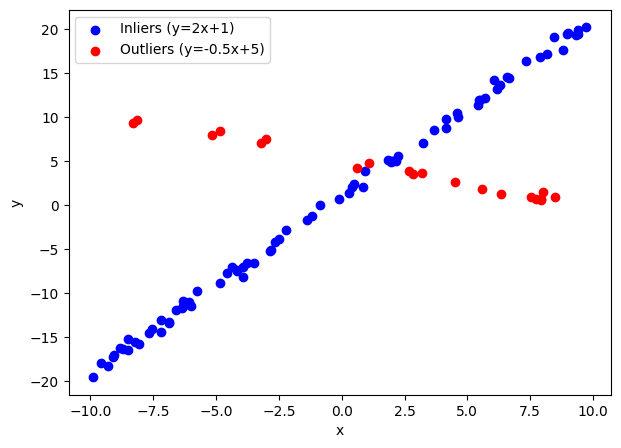

In [ ]:
import pandas as pd

np.random.seed(42)

def generate_data(n_inliers=80, n_outliers=20, noise=0.5):
    # inliners have to follow the line 2x + 1
    xinliers = np.random.uniform(-10, 10, n_inliers)
    yinliers = 2 * xinliers + 1 + np.random.normal(0, noise, n_inliers)

    # outliers follow -0.5x + 5
    xout = np.random.uniform(-10, 10, n_outliers)
    yout = -0.5 * xout + 5 + np.random.normal(0, noise, n_outliers)

    # now add both tg
    x     = np.concatenate([xinliers,  xout])
    y     = np.concatenate([yinliers,  yout])
    label = np.concatenate([np.ones(n_inliers), np.zeros(n_outliers)]).astype(int)

    df = pd.DataFrame({'x': x, 'y': y, 'label': label})
    return df

df = generate_data()

df.to_csv('dataset.csv', index=False)
print(df.head())

plt.figure(figsize=(7,5))
plt.scatter(df[df.label==1].x, df[df.label==1].y, c='blue', label='Inliers (y=2x+1)')
plt.scatter(df[df.label==0].x, df[df.label==0].y, c='red', label='Outliers (y=-0.5x+5)')
plt.xlabel('x');
plt.ylabel('y')
plt.legend()
plt.show()



Least squares line:  y = 1.5694x + 0.7112
Real inlier line:   y = 2x + 1


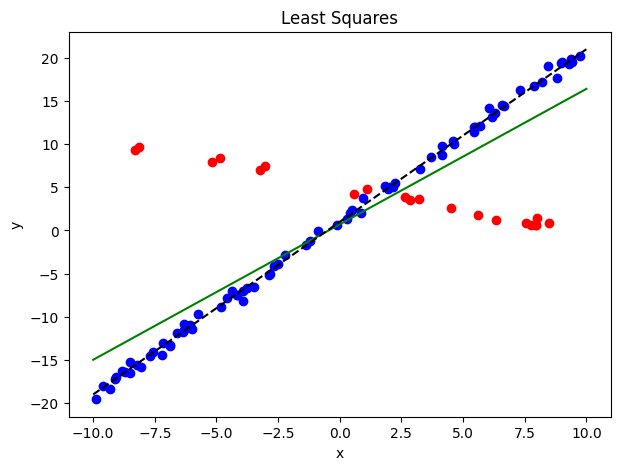

In [ ]:
def least_squares_fit(x, y):
    slope, intercept, r_value, _, _ = linregress(x, y)
    return slope, intercept

ls_slope, ls_intercept = least_squares_fit(df.x.values, df.y.values)
print(f'Least squares line:  y = {ls_slope:.4f}x + {ls_intercept:.4f}')
print(f'Real inlier line:   y = 2x + 1')

x_line = np.linspace(-10, 10, 200)

plt.figure(figsize=(7,5))
plt.scatter(df[df.label==1].x, df[df.label==1].y, c='blue', label='Inliers')
plt.scatter(df[df.label==0].x, df[df.label==0].y, c='red', label='Outliers')
plt.plot(x_line, ls_slope * x_line + ls_intercept, 'g-', label=f'Least Squares: y={ls_slope:.2f}x+{ls_intercept:.2f}')
plt.plot(x_line, 2 * x_line + 1, 'k--', label='True Inlier Line: y=2x+1')
plt.xlabel('x');
plt.ylabel('y')
plt.title('Least Squares')
plt.show()


Least squares is limited when there are outliers, because it minimizes the sum of squared residuals for all data points. Outliers have large residuals, so they cause the line to be pulled away from the inlier line. Since least squares has no way of ignoring outliers, it causes the slope and intercept estimates to become extremely skewed.

In contrast, RANSAC keeps the model supported by the most inliers. It does a better job of ignoring outliers than least squares, because it iteratively samples minimal point sets and evaluates the consensus set.

ransac line: y = 2.0094x + 0.9904
true inlier line:  y = 2x + 1
inliers found: 82


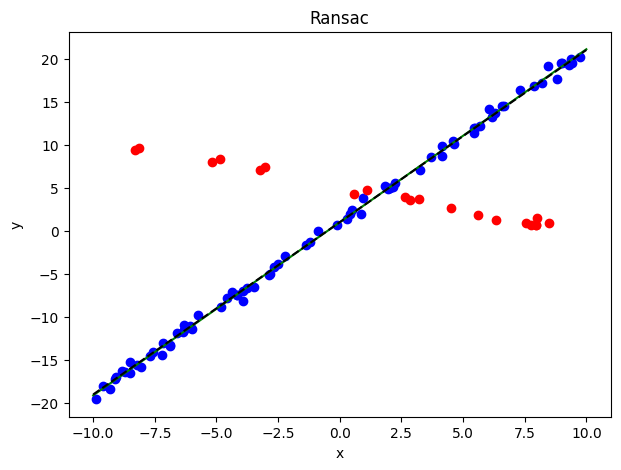

In [ ]:
def point_to_line_distance(x, y, m, b):
    return np.abs(m * x - y + b) / np.sqrt(m**2 + 1)


def fit_line_two_points(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    m = (y2 - y1) / (x2 - x1)
    b = y1 - m * x1
    return m, b


def ransac_line_fit(x, y):
    rng = np.random.default_rng(0)
    n = len(x)
    best_m, best_b = None, None
    best_inlier_count = -1
    best_inlier_mask = None
    inlier_counts = []

    for _ in range(100):
        idx = rng.choice(n, size=2, replace=False)
        m, b = fit_line_two_points((x[idx[0]], y[idx[0]]),
                                   (x[idx[1]], y[idx[1]]))
        if m is None:
            inlier_counts.append(0)
            continue

        dist  = point_to_line_distance(x, y, m, b)
        mask  = dist < 1.0
        count = mask.sum()
        inlier_counts.append(count)

        if count > best_inlier_count:
            best_inlier_count = count
            best_m = m
            best_b = b
            best_inlier_mask  = mask

    if best_inlier_mask.sum() >= 2:
        best_m, best_b = least_squares_fit(x[best_inlier_mask],
                                           y[best_inlier_mask])

    return best_m, best_b, best_inlier_mask, inlier_counts


ransac_m, ransac_b, inlier_mask, inlier_counts = ransac_line_fit(
    df.x.values, df.y.values)

print(f'ransac line: y = {ransac_m:.4f}x + {ransac_b:.4f}')
print(f'true inlier line:  y = 2x + 1')
print(f'inliers found: {inlier_mask.sum()}')


x_line = np.linspace(-10, 10, 200)
plt.figure(figsize=(7,5))
plt.scatter(df[df.label==1].x, df[df.label==1].y, c='blue', label='Inliers')
plt.scatter(df[df.label==0].x, df[df.label==0].y, c='red', label='Outliers')
plt.plot(x_line, ransac_m * x_line + ransac_b, 'g-', label=f'ransac line: y={ransac_m:.2f}x+{ransac_b:.2f}')
plt.plot(x_line, 2 * x_line + 1, 'k--', label='True Inlier Line: y=2x+1')
plt.xlabel('x');
plt.ylabel('y')
plt.title('Ransac')
plt.show()

Problem 3

In [ ]:
def harris_corner_detector(image, sigma=2.5, k=0.04, threshold=0.01):
    img = image.astype(np.float64)

    # To−Do : D e fi n e d e r i v a t i v e o p e r a t o r ( c o n v ol u ti o n )
    dx = np.array([[-1, 0, 1]])
    dy = dx.T

    # To−Do : Compute d e r i v a t i v e s ( c o n v ol u ti o n )
    Ix = convolve(img, dx)
    Iy = convolve(img, dy)

    # To−Do : Compute p ro d u c t s o f d e r i v a t i v e s with Gaussian f i l t e r i n g
    Ixx = gaussian_filter(Ix * Ix, sigma=sigma)
    Iyy = gaussian_filter(Iy * Iy, sigma=sigma)
    Ixy = gaussian_filter(Ix * Iy, sigma=sigma)

    # To−Do : Compute H a r ri s r e s po n s e
    detM = Ixx * Iyy - Ixy ** 2
    traceM = Ixx + Iyy
    R = detM - k * (traceM ** 2)

    # T h r e s hol di ng
    corners = (R > threshold * R.max())

    return R, corners


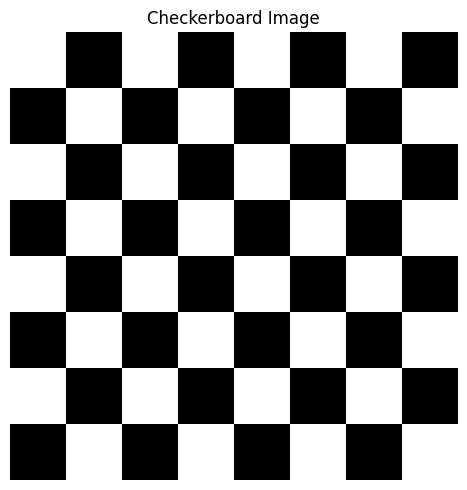

In [ ]:
def create_checkerboard(size=200, num_squares=8):
    square_size  = size // num_squares
    checkerboard = np.zeros((size, size))
    for i in range(num_squares):
        for j in range(num_squares):
            if (i + j) % 2 == 0:
                checkerboard[i * square_size:(i+1) * square_size,
                             j * square_size:(j+1) * square_size] = 1
    return checkerboard

checker = create_checkerboard()

plt.figure(figsize=(5,5))
plt.imshow(checker, cmap='gray', interpolation='nearest')
plt.title('Checkerboard Image')
plt.axis('off')
plt.tight_layout(); plt.show()


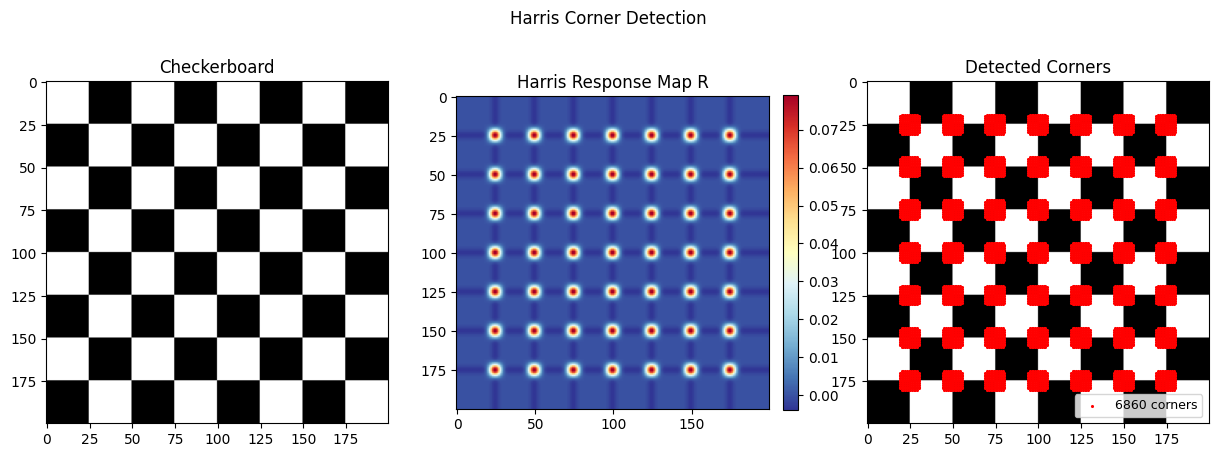

In [ ]:
R, corners = harris_corner_detector(checker, sigma=2.5, k=0.04, threshold=0.01)
corner_coords = np.argwhere(corners)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(checker, cmap='gray')
axes[0].set_title('Checkerboard')

im = axes[1].imshow(R, cmap='RdYlBu_r')
axes[1].set_title('Harris Response Map R')
plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].imshow(checker, cmap='gray')
axes[2].scatter(corner_coords[:,1], corner_coords[:,0],
                c='red', s=5, linewidths=0, label=f'{len(corner_coords)} corners')
axes[2].set_title('Detected Corners')
axes[2].legend(loc='lower right', fontsize=9)

plt.suptitle('Harris Corner Detection')
plt.show()